In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import joblib
import os
import unicodedata
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 6)

print("✓ Libraries imported")
print(f"Current directory: {os.getcwd()}")
# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Salary cap thresholds (2025-26 season)
SALARY_CAP       = 141_000_000   # $141M
LUXURY_TAX_LINE  = 171_000_000   # $171M
FIRST_APRON      = 178_500_000   # $178.5M
SECOND_APRON     = 189_000_000   # $189M

print(f"✓ Random seed set: {RANDOM_SEED}")
print("✓ Salary cap constants loaded")


✓ Libraries imported
Current directory: c:\MSAIML\research_proj\Research-Project\notebooks
✓ Random seed set: 42
✓ Salary cap constants loaded


In [2]:
def calculate_player_medical_score(player_data):
    """
    Calculate comprehensive medical score for a player (0-100).
    
    Components:
    - Injury History (40%): Based on games missed
    - Games Availability (30%): Consistency over 2 seasons
    - Injury Severity (20%): Type and count of injuries
    - Recovery Pattern (10%): Trend analysis
    """
    # Component 1: Injury History (40%)
    games_missed = player_data.get('games_missed', 0)
    games_missed_last = player_data.get('games_missed_last_season', 0)
    
    injury_history_score = 100 * (1 - (games_missed / 82))
    injury_history_score = max(0, min(100, injury_history_score))
    
    # Component 2: Availability (30%)
    avg_games_missed = (games_missed + games_missed_last) / 2
    availability_score = 100 * (1 - (avg_games_missed / 82))
    availability_score = max(0, min(100, availability_score))
    
    # Component 3: Severity (20%)
    minor = player_data.get('minor_count', 0)
    moderate = player_data.get('moderate_count', 0)
    severe = player_data.get('severe_count', 0)
    has_severe = player_data.get('has_severe_injury', 0)
    
    severity_index = minor + (moderate * 3) + (severe * 5)
    severity_score = 100 * np.exp(-severity_index / 10)
    severity_score = max(0, min(100, severity_score))
    
    if has_severe:
        severity_score *= 0.7
    
    # Component 4: Recovery Pattern (10%)
    if games_missed_last > 0:
        recovery_ratio = games_missed / max(games_missed_last, 1)
        if recovery_ratio < 0.5:
            recovery_score = 100
        elif recovery_ratio < 1.0:
            recovery_score = 70
        elif recovery_ratio < 1.5:
            recovery_score = 40
        else:
            recovery_score = 20
    else:
        recovery_score = 100 if games_missed == 0 else 80
    
    # Weighted medical score
    medical_score = (
        0.40 * injury_history_score +
        0.30 * availability_score +
        0.20 * severity_score +
        0.10 * recovery_score
    )
    
    # Grading
    if medical_score >= 85:
        grade, risk = "EXCELLENT", "Very Low"
    elif medical_score >= 70:
        grade, risk = "GOOD", "Low"
    elif medical_score >= 55:
        grade, risk = "FAIR", "Moderate"
    elif medical_score >= 40:
        grade, risk = "POOR", "High"
    else:
        grade, risk = "CRITICAL", "Very High"
    
    return {
        'medical_score': round(medical_score, 1),
        'medical_grade': grade,
        'risk_level': risk,
        'injury_history_score': round(injury_history_score, 1),
        'availability_score': round(availability_score, 1),
        'severity_score': round(severity_score, 1),
        'recovery_score': round(recovery_score, 1),
        'games_missed_current': int(games_missed),
        'games_missed_last': int(games_missed_last),
        'severity_index': round(severity_index, 1),
        'has_severe_history': bool(has_severe)
    }

print("✓ Medical scoring function defined")

✓ Medical scoring function defined


In [3]:
def calculate_roster_health_score(roster):
    """
    Calculate team roster health/fit score (0-100).
    
    Components:
    - Average Medical Score (40%)
    - Depth Health (30%): Top 10 players
    - Injury Risk Distribution (20%): Balance
    - Games Available Projection (10%)
    """
    # Get medical scores
    medical_scores = []
    for _, player in roster.iterrows():
        med = calculate_player_medical_score(player)
        medical_scores.append(med['medical_score'])
    
    # Component 1: Average Medical (40%)
    avg_medical = np.mean(medical_scores) if medical_scores else 50
    
    # Component 2: Depth Health (30%)
    top_10 = sorted(medical_scores, reverse=True)[:10]
    depth_health = np.mean(top_10) if top_10 else 50
    
    # Component 3: Risk Distribution (20%)
    injury_risks = roster['injury_risk_prob'].values
    risk_std = np.std(injury_risks)
    risk_dist_score = 100 * np.exp(-risk_std * 2)
    risk_dist_score = max(0, min(100, risk_dist_score))
    
    # Component 4: Games Available (10%)
    expected_games = []
    for _, player in roster.iterrows():
        injury_prob = player.get('injury_risk_prob', 0.05)
        expected = 82 * (1 - injury_prob * 0.5)
        expected_games.append(expected)
    
    avg_expected = np.mean(expected_games)
    games_avail_score = (avg_expected / 82) * 100
    
    # Weighted score
    health_score = (
        0.40 * avg_medical +
        0.30 * depth_health +
        0.20 * risk_dist_score +
        0.10 * games_avail_score
    )
    
    # Risk categorization
    high_risk = sum(roster['injury_risk_prob'] >= 0.7)
    moderate_risk = sum((roster['injury_risk_prob'] >= 0.5) & (roster['injury_risk_prob'] < 0.7))
    low_risk = sum(roster['injury_risk_prob'] < 0.5)
    
    # Grade
    if health_score >= 80:
        grade = "EXCELLENT"
    elif health_score >= 65:
        grade = "GOOD"
    elif health_score >= 50:
        grade = "AVERAGE"
    elif health_score >= 35:
        grade = "BELOW AVERAGE"
    else:
        grade = "POOR"
    
    return {
        'roster_health_score': round(health_score, 1),
        'health_grade': grade,
        'avg_medical': round(avg_medical, 1),
        'depth_health': round(depth_health, 1),
        'risk_distribution': round(risk_dist_score, 1),
        'games_available': round(games_avail_score, 1),
        'high_risk_players': high_risk,
        'moderate_risk_players': moderate_risk,
        'low_risk_players': low_risk,
        'expected_games_per_player': round(avg_expected, 1)
    }

print("✓ Roster health scoring function defined")

✓ Roster health scoring function defined


In [4]:
def load_models():
    """
    Load Module 1 (Performance) and Module 3 (Injury) models.
    FIXED: Automatically searches multiple paths.
    """
    print("="*70)
    print("LOADING PREDICTION MODELS")
    print("="*70)
    
    # Module 1: Performance Model
    print("\n[Module 1] Loading XGBoost performance model...")
    
    # Try multiple possible paths
    perf_paths = [
        'models/final_model.pkl',           # From notebooks directory
        '../models/final_model.pkl',         # From subdirectory
        './models/final_model.pkl',          # Explicit current
        'final_model.pkl'                    # Root
    ]
    
    performance_model = None
    feature_names = None
    target_names = None
    
    for path in perf_paths:
        if os.path.exists(path):
            try:
                with open(path, 'rb') as f:
                    perf_data = pickle.load(f)
                
                performance_model = perf_data['model']
                feature_names = perf_data['feature_names']
                target_names = perf_data.get('target_names', 
                                              ['target_next_ppg', 'target_next_rpg',
                                               'target_next_apg', 'target_next_mpg',
                                               'target_next_ts_pct'])
                
                print(f"  ✓ Loaded from: {path}")
                print(f"  ✓ Features: {len(feature_names)}")
                break
            except Exception as e:
                continue
    
    if performance_model is None:
        print("\n  ❌ ERROR: Could not find final_model.pkl!")
        print(f"  Searched: {perf_paths}")
        print(f"  Current directory: {os.getcwd()}")
        print("\n  Please check:")
        print("  1. Did you run 02_model_training.ipynb to create the model?")
        print("  2. Is the model saved in the models/ directory?")
        raise FileNotFoundError("Performance model not found!")
    
    # Module 3: Injury Model
    print("\n[Module 3] Loading injury risk model...")
    
    # Try multiple possible paths and filenames
    injury_paths = [
        'models/injury_clf.pkl',
        'models/injury_xgb.pkl',           # Alternative name
        '../models/injury_clf.pkl',
        '../models/injury_xgb.pkl',
        './models/injury_clf.pkl',
        'injury_clf.pkl',
        'injury_xgb.pkl'
    ]
    
    injury_model = None
    
    for path in injury_paths:
        if os.path.exists(path):
            try:
                injury_model = joblib.load(path)
                print(f"  ✓ Loaded from: {path}")
                break
            except Exception as e:
                continue
    
    if injury_model is None:
        print("\n  ❌ ERROR: Could not find injury model!")
        print(f"  Searched: {injury_paths}")
        print(f"  Current directory: {os.getcwd()}")
        print("\n  Available .pkl files in models/:")
        if os.path.exists('models'):
            for f in os.listdir('models'):
                if f.endswith('.pkl'):
                    print(f"    - {f}")
        print("\n  Please check:")
        print("  1. Did you run M3_Injury_Model.ipynb to create the model?")
        print("  2. Is the model saved in the models/ directory?")
        print("  3. Is it named injury_clf.pkl or injury_xgb.pkl?")
        raise FileNotFoundError("Injury model not found!")
    
    print("\n" + "="*70)
    print("ALL MODELS LOADED SUCCESSFULLY")
    print("="*70 + "\n")
    
    return performance_model, feature_names, target_names, injury_model

# Load models
perf_model, features, targets, inj_model = load_models()

LOADING PREDICTION MODELS

[Module 1] Loading XGBoost performance model...
  ✓ Loaded from: ../models/final_model.pkl
  ✓ Features: 54

[Module 3] Loading injury risk model...
  ✓ Loaded from: models/injury_clf.pkl

ALL MODELS LOADED SUCCESSFULLY



In [5]:
# Load data (FIXED PATHS)
print("Loading data files...")

# Try multiple paths for player data
player_paths = [
    'data/processed/player_features_v2_temporal.csv',
    '../data/processed/player_features_v2_temporal.csv',
    './data/processed/player_features_v2_temporal.csv'
]

player_df = None
for path in player_paths:
    if os.path.exists(path):
        player_df = pd.read_csv(path)
        print(f"  ✓ Player data loaded from: {path}")
        break

if player_df is None:
    raise FileNotFoundError(f"Could not find player_features_v2_temporal.csv\nSearched: {player_paths}")

latest_players = player_df.sort_values(['player_name', 'season']).groupby('player_name').last().reset_index()
print(f"  ✓ {len(latest_players)} players")

# Try multiple paths for injury data
injury_paths = [
    'player_injury_score_2020_2025_cleaned.csv',
    '../player_injury_score_2020_2025_cleaned.csv',
    'data/player_injury_score_2020_2025_cleaned.csv',
    '../data/processed/player_injury_score_2020_2025_cleaned.csv'
]

injury_df = None
for path in injury_paths:
    if os.path.exists(path):
        injury_df = pd.read_csv(path)
        print(f"  ✓ Injury data loaded from: {path}")
        break

if injury_df is None:
    raise FileNotFoundError(f"Could not find player_injury_score_2020_2025_cleaned.csv\nSearched: {injury_paths}")

latest_injury = injury_df.sort_values(['Name', 'season']).groupby('Name').last().reset_index()
print(f"  ✓ {len(latest_injury)} injury records")

# Try multiple paths for team data
team_paths = [
    'data/processed/team_features_temporal.csv',
    '../data/processed/team_features_temporal.csv',
    './data/processed/team_features_temporal.csv'
]

team_df = None
for path in team_paths:
    if os.path.exists(path):
        team_df = pd.read_csv(path)
        print(f"  ✓ Team data loaded from: {path}")
        break

if team_df is None:
    raise FileNotFoundError(f"Could not find team_features_temporal.csv\nSearched: {team_paths}")

print(f"  ✓ {len(team_df)} teams\n")

Loading data files...
  ✓ Player data loaded from: ../data/processed/player_features_v2_temporal.csv
  ✓ 770 players
  ✓ Injury data loaded from: ../data/processed/player_injury_score_2020_2025_cleaned.csv
  ✓ 732 injury records
  ✓ Team data loaded from: ../data/processed/team_features_temporal.csv
  ✓ 150 teams



In [6]:
def normalize_name(name):
    """Normalize player names for matching."""
    if not isinstance(name, str):
        return ""
    name = unicodedata.normalize('NFKD', name).encode('ascii', 'ignore').decode('ascii')
    return name.lower().strip()

# Normalize names
latest_players['normalized_name'] = latest_players['player_name'].apply(normalize_name)
latest_injury['normalized_name'] = latest_injury['Name'].apply(normalize_name)

print("="*70)
print("GENERATING PREDICTIONS")
print("="*70)

# Module 1: Performance predictions
print("\n[Module 1] Performance predictions...")
X_perf = latest_players[features].fillna(0)
perf_preds = perf_model.predict(X_perf)

proj_df = pd.DataFrame(perf_preds, columns=targets)
proj_df['player_name'] = latest_players['player_name']
proj_df['normalized_name'] = latest_players['normalized_name']
proj_df['team'] = latest_players['team']
proj_df['position'] = latest_players['position']
print(f"  ✓ {len(proj_df)} players")

# Module 3: Injury predictions
print("\n[Module 3] Injury risk predictions...")
injury_features = [
    'games_missed', 'games_missed_last_season', 'total_days_missed',
    'minor_count', 'moderate_count', 'severe_count', 'has_severe_injury'
]

# Merge injury data
proj_df = proj_df.merge(
    latest_injury[['normalized_name'] + injury_features],
    on='normalized_name',
    how='left'
)

# Fill missing
for col in injury_features:
    proj_df[col] = proj_df[col].fillna(0)

proj_df['has_severe_injury'] = proj_df['has_severe_injury'].astype(int)

# Generate injury predictions
X_injury = proj_df[injury_features].fillna(0)
injury_probs = inj_model.predict_proba(X_injury)[:, 1]

proj_df['injury_risk_prob'] = injury_probs
proj_df['injury_risk_category'] = pd.cut(
    injury_probs,
    bins=[0, 0.3, 0.5, 0.7, 1.0],
    labels=['Low', 'Moderate', 'High', 'Very High']
)
print(f"  ✓ {len(proj_df)} players")

# Medical Module: Calculate medical scores
print("\n[Medical] Calculating health scores...")
medical_scores = []
for _, player in proj_df.iterrows():
    med = calculate_player_medical_score(player)
    medical_scores.append(med)

proj_df['medical_score'] = [m['medical_score'] for m in medical_scores]
proj_df['medical_grade'] = [m['medical_grade'] for m in medical_scores]
proj_df['risk_level'] = [m['risk_level'] for m in medical_scores]
print(f"  ✓ {len(proj_df)} players")

print("\n" + "="*70)
print("ALL PREDICTIONS COMPLETE")
print("="*70 + "\n")

GENERATING PREDICTIONS

[Module 1] Performance predictions...
  ✓ 770 players

[Module 3] Injury risk predictions...
  ✓ 770 players

[Medical] Calculating health scores...
  ✓ 770 players

ALL PREDICTIONS COMPLETE



In [7]:
# Preview predictions
print("Sample player predictions:\n")
display_cols = ['player_name', 'team', 'target_next_ppg', 'target_next_mpg',
                'injury_risk_prob', 'injury_risk_category', 'medical_score', 'medical_grade']
print(proj_df[display_cols].head(15).to_string(index=False))

Sample player predictions:

      player_name team  target_next_ppg  target_next_mpg  injury_risk_prob injury_risk_category  medical_score medical_grade
       A.J. Green  MIL         7.088680        19.740440          0.582656                 High           81.4          GOOD
      A.J. Lawson  TOR         4.331171         9.455247          0.660725                 High          100.0     EXCELLENT
       AJ Griffin  ATL         1.525460         3.505330          0.660725                 High          100.0     EXCELLENT
       AJ Johnson  WAS         6.604563        19.474136          0.660725                 High          100.0     EXCELLENT
     Aaron Gordon  DEN        13.646118        26.140017          0.200250                  Low           56.6          FAIR
    Aaron Holiday  HOU         5.402565        12.291382          0.735591            Very High           18.0      CRITICAL
    Aaron Nesmith  IND        10.584244        24.007719          0.712525            Very High  

In [8]:
def calculate_fit_penalty(roster):
    """Calculate roster fit penalty based on usage concentration."""
    if len(roster) == 0:
        return 1.0

    usage_rates = roster.get('usage_rate', pd.Series([0.2] * len(roster)))
    usage_std = np.std(usage_rates)

    # Lower std = more balanced = better
    balance_factor = np.exp(-usage_std * 2)
    fit_penalty = 0.85 + (0.15 * balance_factor)

    return min(1.0, max(0.85, fit_penalty))


def calculate_team_score(roster, sampled_stats):
    """Calculate team offensive rating from sampled player stats."""
    if len(roster) == 0:
        return 100

    # Weighted PPG by minutes played
    total_mpg = sampled_stats['mpg'].sum() if 'mpg' in sampled_stats.columns else sampled_stats.get('target_next_mpg', pd.Series([20]*len(sampled_stats))).sum()
    if total_mpg == 0:
        return 100

    mpg_col  = 'mpg'  if 'mpg'  in sampled_stats.columns else 'target_next_mpg'
    ppg_col  = 'ppg'  if 'ppg'  in sampled_stats.columns else 'target_next_ppg'
    weighted_ppg = (sampled_stats[ppg_col] * sampled_stats[mpg_col]).sum() / (total_mpg / 5)

    # Apply fit penalty
    fit_penalty = calculate_fit_penalty(roster)
    team_score  = weighted_ppg * fit_penalty

    return team_score


def predict_wins(team_score):
    """Convert team score to predicted wins (linear approximation, clipped [5, 75])."""
    baseline = 100  # League average team score
    wins = 41 + (team_score - baseline) * 0.4
    return float(np.clip(wins, 5, 75))


def wins_to_playoff_prob(wins):
    """Convert wins to playoff probability (smooth piecewise linear)."""
    if wins >= 50:
        return 0.95
    elif wins >= 45:
        return 0.75
    elif wins >= 42:
        return 0.50
    elif wins >= 38:
        return 0.25
    else:
        return 0.05


print("✓ Team evaluation functions defined (M2+M3 versions)")


✓ Team evaluation functions defined (M2+M3 versions)


In [9]:
STD_DEVS = {
    'target_next_ppg': 3.0,
    'target_next_rpg': 1.5,   # updated from M3 integration
    'target_next_apg': 1.2,   # updated from M3 integration
    'target_next_mpg': 5.0,   # updated from M3 integration
    'target_next_ts_pct': 0.04  # updated from M3 integration
}

def run_injury_adjusted_simulation(roster, n_sims=1000):
    """
    Monte Carlo simulation with injury risk from Module 3.
    """
    results = []
    
    for _ in range(n_sims):
        sampled = roster.copy()
        
        # Sample from normal distributions
        for col, std in STD_DEVS.items():
            sampled[col] = np.maximum(0, np.random.normal(roster[col], std))
        
        # Apply injury effects
        for idx, row in sampled.iterrows():
            injury_prob = row['injury_risk_prob']
            
            if np.random.random() < injury_prob:
                severity = 0.4 + (injury_prob * 0.4)  # 40-80% reduction
                sampled.at[idx, 'target_next_ppg'] *= (1 - severity)
                sampled.at[idx, 'target_next_rpg'] *= (1 - severity)
                sampled.at[idx, 'target_next_apg'] *= (1 - severity)
                sampled.at[idx, 'target_next_mpg'] *= (1 - severity)
        
        # Calculate wins
        score = calculate_team_score(roster, sampled)
        wins = predict_wins(score)
        results.append(wins)
    
    return np.array(results)

print("✓ Injury-adjusted Monte Carlo ready")

✓ Injury-adjusted Monte Carlo ready


In [10]:
# ── M3: SALARY CAP & FINANCIAL ANALYSIS ─────────────────────────────────────

def get_player_financials(player_name, salary_df):
    """
    Get complete financial profile for a player.

    Returns salary, contract value, NPV, cap hit, luxury tax risk, etc.
    """
    player = salary_df[salary_df['name'] == player_name]

    if player.empty:
        return {
            'name': player_name,
            'current_salary': 0,
            'total_contract_value': 0,
            'avg_salary': 0,
            'npv_contract': 0,
            'cap_hit_percent': 0,
            'luxury_tax_risk': 0,
            'years_remaining': 0
        }

    return {
        'name': player_name,
        'current_salary':       float(player.iloc[0]['salary']),
        'total_contract_value': float(player['salary'].sum()),
        'avg_salary':           float(player['avg_salary'].iloc[0]),
        'npv_contract':         float(player['npv_salary'].sum()),
        'cap_hit_percent':      float(player.iloc[0]['cap_hit_percent']),
        'luxury_tax_risk':      float(player.iloc[0]['luxury_tax_risk']),
        'years_remaining':      int(player.iloc[0]['years_remaining'])
    }


def team_financial_summary(player_names, salary_df):
    """
    Aggregate financial data for a list of players.

    Returns total salary, NPV, cap hit, luxury tax risk, etc.
    """
    players = [get_player_financials(name, salary_df) for name in player_names]

    return {
        'players':        players,
        'total_salary':   sum(p['current_salary']       for p in players),
        'total_npv':      sum(p['npv_contract']         for p in players),
        'total_cap_hit':  sum(p['cap_hit_percent']      for p in players),
        'luxury_tax_risk':sum(p['luxury_tax_risk']      for p in players),
        'total_years':    sum(p['years_remaining']      for p in players)
    }


def calculate_financial_score(outgoing_financials, incoming_financials):
    """
    Calculate financial impact score (0-100).

    Higher score = better financial outcome (saving money, reducing tax).

    Formula:
    - 40% Net cap change
    - 30% Luxury tax change
    - 30% NPV change
    """
    net_cap      = incoming_financials['total_salary'] - outgoing_financials['total_salary']
    lux_tax_chg  = incoming_financials['luxury_tax_risk'] - outgoing_financials['luxury_tax_risk']
    npv_chg      = incoming_financials['total_npv']    - outgoing_financials['total_npv']

    # Weighted financial pressure (positive = spending more = bad)
    pressure = (
        0.4 * (net_cap     / 1_000_000) +
        0.3 *  lux_tax_chg             +
        0.3 * (npv_chg     / 1_000_000)
    )

    # Map pressure to 0-100 score  (saving = higher score)
    if   pressure <= -10: score = 100
    elif pressure <=  -5: score = 85 + (pressure + 5) * 3
    elif pressure <=   0: score = 70 + pressure * 3
    elif pressure <=   5: score = 50 - pressure * 4
    elif pressure <=  10: score = 30 - (pressure - 5) * 3
    else:                 score = 15 - min((pressure - 10) * 1.5, 15)

    score = max(0, min(100, score))

    return {
        'score':             round(score, 1),
        'net_cap_change':    round(net_cap, 2),
        'luxury_tax_change': round(lux_tax_chg, 3),
        'npv_change':        round(npv_chg, 2),
        'financial_pressure':round(pressure, 2),
        'outgoing_salary':   round(outgoing_financials['total_salary'], 2),
        'incoming_salary':   round(incoming_financials['total_salary'], 2)
    }


print("✓ M3 financial analysis functions defined")
print("  → get_player_financials()")
print("  → team_financial_summary()")
print("  → calculate_financial_score()")


✓ M3 financial analysis functions defined
  → get_player_financials()
  → team_financial_summary()
  → calculate_financial_score()


In [11]:
# ── TRADE SCORING (6-FACTOR) ─────────────────────────────────────────────────

def calc_trade_score(delta_wins, playoff_change, injury_change,
                     health_change, medical_change, financial_score=None):
    """
    Calculate overall trade score (0-100).

    6-FACTOR FORMULA (with M3 salary data):
      45% Win change  |  18% Playoff prob  |  13% Injury risk
       9% Health      |   5% Medical       |  10% Financial

    5-FACTOR FALLBACK (no salary data):
      50% Win change  |  20% Playoff prob  |  15% Injury risk
      10% Health      |   5% Medical
    """
    win_score     = max(0, min(100, 50 + delta_wins   * 10))
    playoff_score = max(0, min(100, 50 + playoff_change * 100))
    injury_score  = max(0, min(100, 50 - injury_change  * 100))
    health_score  = max(0, min(100, 50 + health_change  /  2))
    medical_score = max(0, min(100, 50 + medical_change /  2))

    if financial_score is not None:
        overall = (
            0.45 * win_score     +
            0.18 * playoff_score +
            0.13 * injury_score  +
            0.09 * health_score  +
            0.05 * medical_score +
            0.10 * financial_score
        )
    else:
        overall = (
            0.50 * win_score     +
            0.20 * playoff_score +
            0.15 * injury_score  +
            0.10 * health_score  +
            0.05 * medical_score
        )

    return round(overall, 1)


def get_trade_rating(score):
    """Convert numeric score to qualitative rating."""
    if   score >= 70: return "BENEFICIAL"
    elif score >= 55: return "SLIGHTLY POSITIVE"
    elif score >= 45: return "NEUTRAL"
    elif score >= 30: return "SLIGHTLY NEGATIVE"
    else:             return "HARMFUL"


def classify_trade(score_a, score_b, delta_a, delta_b):
    """Classify trade based on fairness and win-change quality."""
    fairness = 100 - abs(score_a - score_b)
    quality  = (score_a + score_b) / 2

    if   fairness >= 80 and quality >= 50: return "FAIR & BENEFICIAL"
    elif fairness >= 80:                   return "FAIR BUT NEUTRAL"
    elif abs(delta_a - delta_b) > 5:
        winner = "TEAM A" if delta_a > delta_b else "TEAM B"
        return f"HEAVILY FAVORS {winner}"
    elif quality >= 60:                    return "WIN-WIN TRADE"
    else:                                  return "MODERATE TRADE"


print("✓ 6-factor trade scoring functions defined")
print("  → calc_trade_score()  (5-factor fallback when no salary data)")
print("  → get_trade_rating()")
print("  → classify_trade()")


✓ 6-factor trade scoring functions defined
  → calc_trade_score()  (5-factor fallback when no salary data)
  → get_trade_rating()
  → classify_trade()


In [12]:
def analyze_complete_trade(team_a_id, team_b_id, outgoing_a, outgoing_b,
                           salary_df=None):
    """
    Complete trade analysis: Monte Carlo simulation + optional M3 salary cap.

    Parameters
    ----------
    team_a_id, team_b_id : str   Team abbreviations (e.g. 'LAL', 'ATL')
    outgoing_a, outgoing_b : list  Player names being traded by each team
    salary_df : pd.DataFrame, optional
        Salary data with columns: name, salary, avg_salary, npv_salary,
        cap_hit_percent, luxury_tax_risk, years_remaining.
        When provided, enables the 6-factor scoring formula.

    Returns
    -------
    dict with full results including win arrays and all scores.
    """
    print(f"\n{'='*70}")
    print("COMPLETE TRADE ANALYSIS  (M2 + M3)")
    print(f"{'='*70}")
    print(f"Trade: {team_a_id} ↔ {team_b_id}")
    print(f"  {team_a_id} sends: {', '.join(outgoing_a)}")
    print(f"  {team_b_id} sends: {', '.join(outgoing_b)}")

    # ── Normalize names ────────────────────────────────────────────────────
    out_a_norm = [normalize_name(p) for p in outgoing_a]
    out_b_norm = [normalize_name(p) for p in outgoing_b]

    # ── Build rosters ──────────────────────────────────────────────────────
    roster_a = proj_df[proj_df['team'] == team_a_id].copy()
    roster_b = proj_df[proj_df['team'] == team_b_id].copy()

    if roster_a.empty or roster_b.empty:
        print("\n❌ Error: Could not find one or both rosters.")
        return None

    players_a = roster_a[roster_a['normalized_name'].isin(out_a_norm)]
    players_b = roster_b[roster_b['normalized_name'].isin(out_b_norm)]

    print(f"\n{'-'*70}")
    print("TRADED PLAYERS")
    print(f"{'-'*70}")
    print(f"\nFrom {team_a_id}:")
    for _, p in players_a.iterrows():
        print(f"  • {p['player_name']}: {p['target_next_ppg']:.1f} PPG, "
              f"Injury: {p['injury_risk_prob']:.1%} ({p['injury_risk_category']}), "
              f"Medical: {p['medical_score']:.1f}/100 ({p['medical_grade']})")
    print(f"\nFrom {team_b_id}:")
    for _, p in players_b.iterrows():
        print(f"  • {p['player_name']}: {p['target_next_ppg']:.1f} PPG, "
              f"Injury: {p['injury_risk_prob']:.1%} ({p['injury_risk_category']}), "
              f"Medical: {p['medical_score']:.1f}/100 ({p['medical_grade']})")

    # ── Post-trade rosters ─────────────────────────────────────────────────
    post_a = pd.concat([roster_a[~roster_a['normalized_name'].isin(out_a_norm)], players_b])
    post_b = pd.concat([roster_b[~roster_b['normalized_name'].isin(out_b_norm)], players_a])

    # ── 1. Roster health analysis ──────────────────────────────────────────
    print(f"\n{'-'*70}")
    print("ROSTER HEALTH ANALYSIS")
    print(f"{'-'*70}")

    pre_health_a  = calculate_roster_health_score(roster_a)
    post_health_a = calculate_roster_health_score(post_a)
    pre_health_b  = calculate_roster_health_score(roster_b)
    post_health_b = calculate_roster_health_score(post_b)

    for tid, pre, post in [(team_a_id, pre_health_a, post_health_a),
                            (team_b_id, pre_health_b, post_health_b)]:
        chg = post['roster_health_score'] - pre['roster_health_score']
        print(f"\n{tid} Roster Health:")
        print(f"  Pre-Trade:  {pre['roster_health_score']:.1f}/100 ({pre['health_grade']})")
        print(f"  Post-Trade: {post['roster_health_score']:.1f}/100 ({post['health_grade']})")
        print(f"  Change:     {chg:+.1f}")

    # ── 2. Monte Carlo simulations ─────────────────────────────────────────
    print(f"\n{'-'*70}")
    print("RUNNING MONTE CARLO SIMULATIONS (1 000 iterations each)")
    print(f"{'-'*70}\n")

    print(f"Simulating {team_a_id}...")
    pre_wins_a  = run_injury_adjusted_simulation(roster_a, n_sims=1000)
    post_wins_a = run_injury_adjusted_simulation(post_a,   n_sims=1000)

    print(f"Simulating {team_b_id}...")
    pre_wins_b  = run_injury_adjusted_simulation(roster_b, n_sims=1000)
    post_wins_b = run_injury_adjusted_simulation(post_b,   n_sims=1000)

    # ── 3. Delta metrics ───────────────────────────────────────────────────
    delta_a = float(post_wins_a.mean() - pre_wins_a.mean())
    delta_b = float(post_wins_b.mean() - pre_wins_b.mean())

    ci_a = (round(float(np.percentile(post_wins_a - pre_wins_a,  5)), 2),
            round(float(np.percentile(post_wins_a - pre_wins_a, 95)), 2))
    ci_b = (round(float(np.percentile(post_wins_b - pre_wins_b,  5)), 2),
            round(float(np.percentile(post_wins_b - pre_wins_b, 95)), 2))

    playoff_ch_a = wins_to_playoff_prob(post_wins_a.mean()) - wins_to_playoff_prob(pre_wins_a.mean())
    playoff_ch_b = wins_to_playoff_prob(post_wins_b.mean()) - wins_to_playoff_prob(pre_wins_b.mean())

    inj_ch_a = (float(players_b['injury_risk_prob'].mean() - players_a['injury_risk_prob'].mean())
                if not players_a.empty and not players_b.empty else 0.0)
    inj_ch_b = -inj_ch_a

    health_ch_a = post_health_a['roster_health_score'] - pre_health_a['roster_health_score']
    health_ch_b = post_health_b['roster_health_score'] - pre_health_b['roster_health_score']

    med_ch_a = (float(players_b['medical_score'].mean() - players_a['medical_score'].mean())
                if not players_a.empty and not players_b.empty else 0.0)
    med_ch_b = -med_ch_a

    # ── 4. M3 Financial Analysis (optional) ───────────────────────────────
    financial_a = financial_b = None
    if salary_df is not None:
        try:
            out_fin_a = team_financial_summary(outgoing_a, salary_df)
            in_fin_a  = team_financial_summary(outgoing_b, salary_df)
            out_fin_b = team_financial_summary(outgoing_b, salary_df)
            in_fin_b  = team_financial_summary(outgoing_a, salary_df)

            financial_a = calculate_financial_score(out_fin_a, in_fin_a)
            financial_b = calculate_financial_score(out_fin_b, in_fin_b)
            print("\n✓ Financial (M3) analysis completed")
        except Exception as exc:
            print(f"\n⚠ Financial analysis skipped: {exc}")

    # ── 5. Composite scores ────────────────────────────────────────────────
    score_a = calc_trade_score(delta_a, float(playoff_ch_a), inj_ch_a,
                               health_ch_a, med_ch_a,
                               financial_a['score'] if financial_a else None)
    score_b = calc_trade_score(delta_b, float(playoff_ch_b), inj_ch_b,
                               health_ch_b, med_ch_b,
                               financial_b['score'] if financial_b else None)

    rating_a  = get_trade_rating(score_a)
    rating_b  = get_trade_rating(score_b)
    fairness  = round(100 - abs(score_a - score_b), 1)
    combined  = round((score_a + score_b) / 2, 1)
    classif   = classify_trade(score_a, score_b, delta_a, delta_b)

    # ── 6. Print results ───────────────────────────────────────────────────
    print(f"\n{'='*70}")
    print("FINAL TRADE EVALUATION")
    print(f"{'='*70}")

    for tid, sc, rt, dw, ci, pc, ic, hc, mc, fi in [
        (team_a_id, score_a, rating_a, delta_a, ci_a,
         playoff_ch_a, inj_ch_a, health_ch_a, med_ch_a, financial_a),
        (team_b_id, score_b, rating_b, delta_b, ci_b,
         playoff_ch_b, inj_ch_b, health_ch_b, med_ch_b, financial_b),
    ]:
        print(f"\n{tid}:")
        print(f"  Overall Score:       {sc:.1f}/100  →  {rt}")
        print(f"  Win Change:          {dw:+.2f} wins")
        print(f"  90% CI:              [{ci[0]:+.1f}, {ci[1]:+.1f}]")
        print(f"  Playoff Change:      {pc:+.1%}")
        print(f"  Injury Risk Change:  {ic:+.1%}  "
              f"({'⬇️ BETTER' if ic < 0 else '⬆️ WORSE' if ic > 0 else '→ SAME'})")
        print(f"  Health Change:       {hc:+.1f}  "
              f"({'⬆️ BETTER' if hc > 0 else '⬇️ WORSE' if hc < 0 else '→ SAME'})")
        print(f"  Medical Change:      {mc:+.1f}  "
              f"({'⬆️ BETTER' if mc > 0 else '⬇️ WORSE' if mc < 0 else '→ SAME'})")
        if fi:
            print(f"  Financial Score:     {fi['score']:.1f}/100  "
                  f"(cap Δ ${fi['net_cap_change']/1e6:+.1f}M, "
                  f"NPV Δ ${fi['npv_change']/1e6:+.1f}M)")

    print(f"\nOverall Assessment:")
    print(f"  Fairness:            {fairness}/100")
    print(f"  Combined Quality:    {combined}/100")
    print(f"  Classification:      {classif}")
    winner = team_a_id if delta_a > delta_b else team_b_id
    margin = abs(delta_a - delta_b)
    print(f"  Winner:              {winner} (+{margin:.1f} wins)")
    print(f"  M3 Financial:        {'ENABLED' if salary_df is not None else 'DISABLED (no salary_df)'}")

    print(f"\n{'='*70}")
    print("✓ Complete analysis finished")
    print(f"{'='*70}\n")

    return {
        'team_a_id':    team_a_id,
        'team_b_id':    team_b_id,
        'team_a_score': score_a,
        'team_b_score': score_b,
        'team_a_delta': delta_a,
        'team_b_delta': delta_b,
        'fairness':     fairness,
        'combined':     combined,
        'overall':      classif,
        'pre_wins_a':   pre_wins_a,
        'post_wins_a':  post_wins_a,
        'pre_wins_b':   pre_wins_b,
        'post_wins_b':  post_wins_b,
        'financial_a':  financial_a,
        'financial_b':  financial_b,
    }

print("✓ analyze_complete_trade() ready  (M2 + optional M3)")


✓ analyze_complete_trade() ready  (M2 + optional M3)


In [13]:
def plot_complete_trade_analysis(results, team_a_name, team_b_name):
    """
    Comprehensive visualization of trade impact.
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Plot 1: Team A Win Distribution
    ax1 = axes[0, 0]
    pre_a = results['pre_wins_a']
    post_a = results['post_wins_a']
    
    sns.histplot(pre_a, color='gray', alpha=0.5, label='Pre-Trade', ax=ax1, kde=True)
    sns.histplot(post_a, color='blue', alpha=0.5, label='Post-Trade', ax=ax1, kde=True)
    ax1.axvline(pre_a.mean(), color='red', linestyle='--', linewidth=2, label='Pre Mean')
    ax1.axvline(post_a.mean(), color='green', linestyle='-', linewidth=2, label='Post Mean')
    ax1.set_title(f"{team_a_name} Win Distribution", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Expected Wins", fontsize=12)
    ax1.set_ylabel("Frequency", fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Team B Win Distribution
    ax2 = axes[0, 1]
    pre_b = results['pre_wins_b']
    post_b = results['post_wins_b']
    
    sns.histplot(pre_b, color='gray', alpha=0.5, label='Pre-Trade', ax=ax2, kde=True)
    sns.histplot(post_b, color='blue', alpha=0.5, label='Post-Trade', ax=ax2, kde=True)
    ax2.axvline(pre_b.mean(), color='red', linestyle='--', linewidth=2, label='Pre Mean')
    ax2.axvline(post_b.mean(), color='green', linestyle='-', linewidth=2, label='Post Mean')
    ax2.set_title(f"{team_b_name} Win Distribution", fontsize=14, fontweight='bold')
    ax2.set_xlabel("Expected Wins", fontsize=12)
    ax2.set_ylabel("Frequency", fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Impact Scores Comparison
    ax3 = axes[1, 0]
    scores = [results['team_a_score'], results['team_b_score']]
    teams = [team_a_name, team_b_name]
    colors = ['#2ecc71' if s >= 60 else '#f39c12' if s >= 45 else '#e74c3c' for s in scores]
    
    bars = ax3.bar(teams, scores, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
    ax3.set_ylabel('Overall Impact Score', fontsize=12)
    ax3.set_title('Trade Impact Scores', fontsize=14, fontweight='bold')
    ax3.set_ylim(0, 100)
    ax3.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='Neutral (50)')
    ax3.grid(True, alpha=0.3, axis='y')
    ax3.legend()
    
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom', 
                fontsize=12, fontweight='bold')
    
    # Plot 4: Win Change Comparison
    ax4 = axes[1, 1]
    deltas = [results['team_a_delta'], results['team_b_delta']]
    delta_colors = ['#2ecc71' if d > 0 else '#e74c3c' for d in deltas]
    
    bars = ax4.bar(teams, deltas, color=delta_colors, alpha=0.7, edgecolor='black', linewidth=2)
    ax4.set_ylabel('Win Change', fontsize=12)
    ax4.set_title('Projected Win Change', fontsize=14, fontweight='bold')
    ax4.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax4.grid(True, alpha=0.3, axis='y')
    
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:+.1f}', ha='center', 
                va='bottom' if height > 0 else 'top',
                fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

print("✓ Visualization function ready")

✓ Visualization function ready


In [14]:
def search_players(query, team=None):
    """
    Search for players with complete stats.
    """
    query_norm = normalize_name(query)
    
    if team:
        matches = proj_df[
            (proj_df['normalized_name'].str.contains(query_norm, na=False)) &
            (proj_df['team'] == team)
        ]
    else:
        matches = proj_df[proj_df['normalized_name'].str.contains(query_norm, na=False)]
    
    if matches.empty:
        print("No matches found.")
    else:
        display_cols = ['player_name', 'team', 'position', 'target_next_ppg',
                       'injury_risk_prob', 'injury_risk_category', 
                       'medical_score', 'medical_grade']
        print(matches[display_cols].to_string(index=False))
        print(f"\nFound {len(matches)} player(s)")

print("✓ Search function ready")
print("\nExample: search_players('lebron')")

✓ Search function ready

Example: search_players('lebron')



COMPLETE TRADE ANALYSIS  (M2 + M3)
Trade: LAL ↔ ATL
  LAL sends: LeBron James
  ATL sends: Trae Young

----------------------------------------------------------------------
TRADED PLAYERS
----------------------------------------------------------------------

From LAL:
  • LeBron James: 26.1 PPG, Injury: 18.2% (Low), Medical: 74.7/100 (GOOD)

From ATL:
  • Trae Young: 21.0 PPG, Injury: 18.4% (Low), Medical: 74.0/100 (GOOD)

----------------------------------------------------------------------
ROSTER HEALTH ANALYSIS
----------------------------------------------------------------------

LAL Roster Health:
  Pre-Trade:  64.8/100 (AVERAGE)
  Post-Trade: 64.8/100 (AVERAGE)
  Change:     +0.0

ATL Roster Health:
  Pre-Trade:  72.0/100 (GOOD)
  Post-Trade: 72.0/100 (GOOD)
  Change:     +0.0

----------------------------------------------------------------------
RUNNING MONTE CARLO SIMULATIONS (1 000 iterations each)
----------------------------------------------------------------------

S

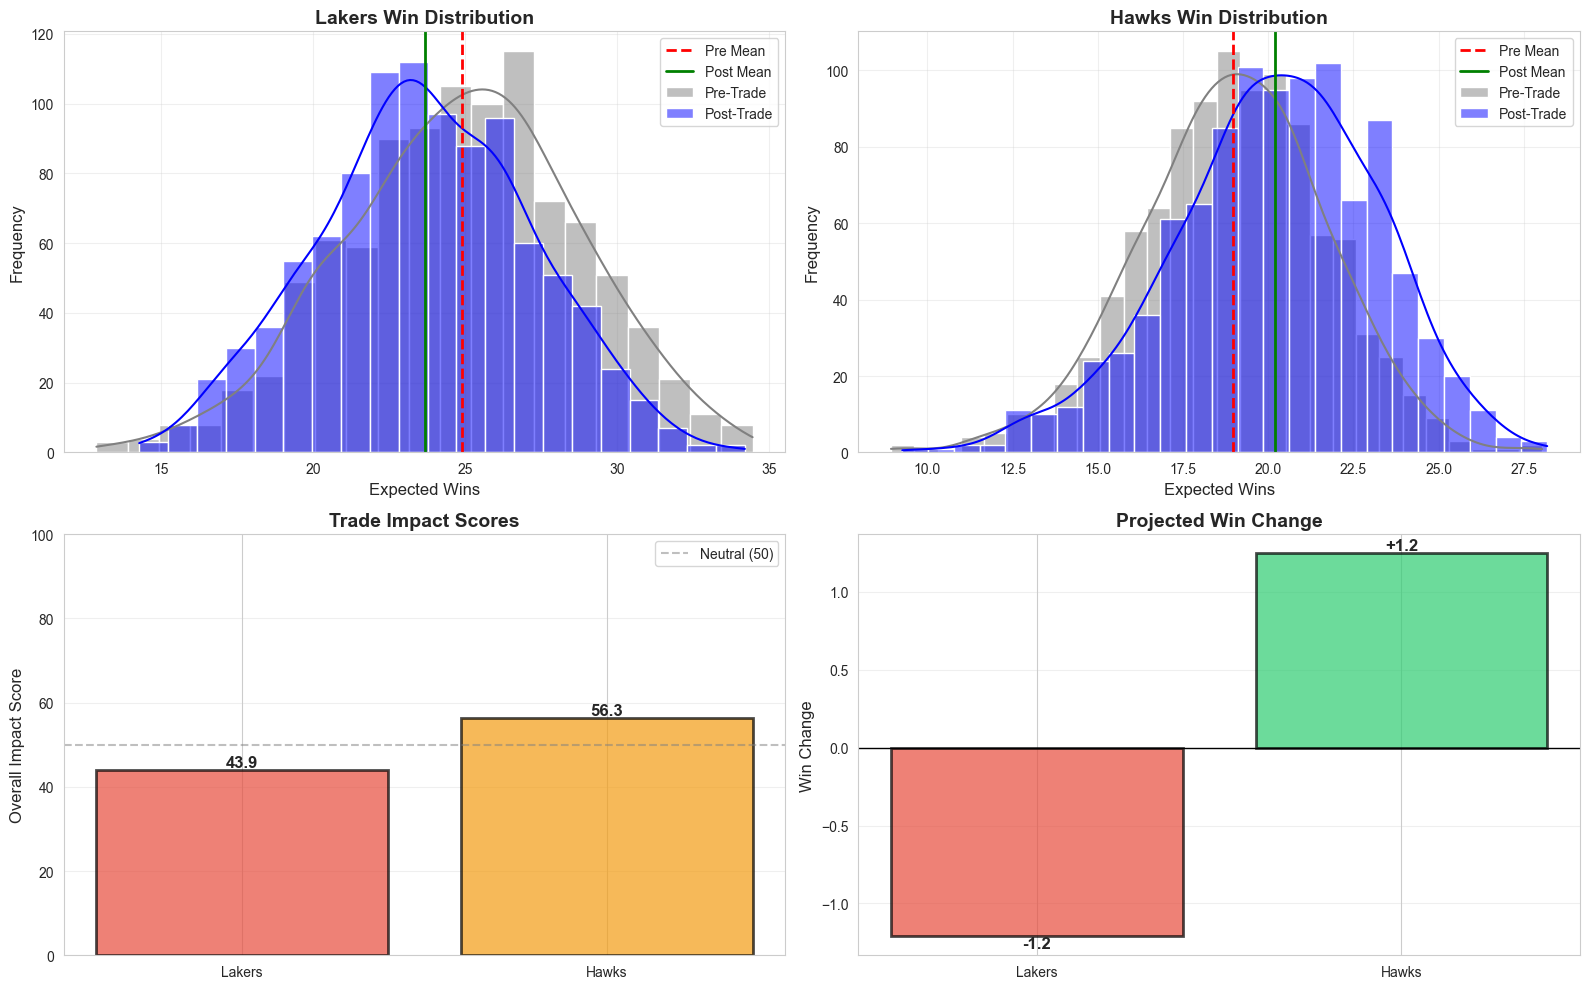

In [19]:
# ── Example Trade Analysis ───────────────────────────────────────────────────
# Basic usage (M2 only — no salary data required):
results = analyze_complete_trade(
    team_a_id  = 'LAL',
    team_b_id  = 'ATL',
    outgoing_a = ['LeBron James'],
    outgoing_b = ['Trae Young']
)

# With M3 salary cap analysis (optional):
# First load your salary CSV:
salary_df = pd.read_csv('../data/processed/Nba Player Salaries.csv')
# Required columns: name, salary, avg_salary, npv_salary,
#                   cap_hit_percent, luxury_tax_risk, years_remaining
#
# Then pass it in:
results = analyze_complete_trade(
      team_a_id='LAL', team_b_id='ATL',
      outgoing_a=['LeBron James'], outgoing_b=['Trae Young'],
      salary_df=salary_df           # ← enables 6-factor scoring
  )

if results:
    plot_complete_trade_analysis(results, 'Lakers', 'Hawks')
